# This is a minimal solve_ivp example of the Pandya+22 "sapphire" SAM
### This project is a work in progress.
### Do not publicly share without permission from Viraj Pandya (vgp2108@columbia.edu)

In [1]:
# load modules
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from scipy.interpolate import RegularGridInterpolator, UnivariateSpline, InterpolatedUnivariateSpline
from scipy.ndimage import gaussian_filter1d
from glob import glob
import multiprocessing
from scipy.integrate import simps, solve_ivp, trapz
import h5py 
from timeit import default_timer as timer
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [2]:
halo_name = 'm12m' # can be one of m10q, m10y, m10z, m11a, m11b, m11c, m11q, m11f, m11v, m12i, m12f, m12m

tfire = Table.read('../data/pandya23_m12m.dat',format='ascii')

In [3]:
###### UV background suppression of fb*Mdot_vir (relevant for m10 halos)

# First compute the "Filtering Mass" at which halos accrete only half of the incoming baryon fraction fb*Mdot_vir (Gnedin+00)
# The following is basically copied from Rachel's SAM code (module = stars.cc)
# This is the analytic model from Appendix B of Kravtsov+04

def m_filt(z, z_overlap=9.0, z_reionize=3.5, z_squelch=8.0):
    # from Rachel's param.sample, follows Kravtsov+04 appendix B
    # z1=z_overlap, z2=z_reionize, z_squelch = when suppression ('squelching') turned on
    # Rachel tuned these parameters to reproduce Okamoto+08, so do not over-interpret parameter names or modify values
    # NOTE: I should probably re-write this so the parameters reflect their intended meaning (eg z_reionize >> 3.5)
    
    a_o = 1.0/(1+z_overlap) # scale factor where multiple HII regions BEGIN TO overlap
    a_r = 1.0/(1+z_reionize) # scale factor of complete reionization
    a = 1.0 / (1+z) # current scale factor
    
    # Jeans mass in Msun; 0.59 is mean molecular weight
    m_jeans = 2.5E11 * Planck15.h**-1 * np.sqrt(Planck15.Om0)**-1 * (0.59)**-1.5 
    
    alpha = 6.0 # power that controls growth rate of UV background flux (Kravtsov+04 fixed alpha=6)
    
    if a < a_o:
        f_a = (3.0 * a / ((2.0+alpha)*(5.0+2.0*alpha))) * (a/a_o)**alpha
    elif a >= a_o and a <= a_r: 
        f_a = (3.0/a)*a_o**2*(1.0/(2+alpha) - (2*(a/a_o)**-0.5)/(5+2*alpha)) + a**2/10. - (a_o**2/10.)*(5-4*(a/a_o)**-0.5)
    elif a > a_r: 
        f1 = a_o**2*(1/(2+alpha) - 2*(a/a_o)**-0.5/(5+2*alpha))
        f2 = a_r**2/10.*(5-4*(a/a_r)**-0.5)
        f3 = a_o**2/10.*(5-4*(a/a_o)**-0.5)
        f4 = a*a_r/3. - a_r**2/3.*(3-2*(a/a_r)**-0.5)
        f_a = 3.0/a * (f1 + f2 - f3 + f4)
        
    mf = m_jeans * f_a**1.5
    
    # constant from Rachel's stars.cc implementation
    # this ensures Mfilt defined in this way matches the Okamoto+08 "M_characteristic" definition normalization
    Mfilt_factor = 0.0933 
    
    return Mfilt_factor * mf

# Next compute the actual suppression factor f_UV that depends on the filtering mass 
# Halos with Mvir >> Mfilt will have f_UV ~ 1 (no suppression), whereas much lower mass halos tend to f_UV ~ 0
# This is eqn (1) of Okamoto+08 who studied the UV background in hydro simulations
# NOTE: I should update this to use Faucher-Giguere+09 (or 18) to be consistent with FIRE
def collapse_fraction(m,mfilt):
    alpha = 2.0
    
    fcoll = (1+(2**(alpha/3.)-1.)*(m/mfilt)**-alpha)**(-3/alpha)
    
    return fcoll

In [4]:
"""
Now interpolate Wiersma09 -- see my successful demonstration of this code wiersma09.ipynb 
"""

### glob the Wiersma+09 cooling tables for all redshifts
files_W09 = glob('../sapphire/coolfunc/data/wiersma09/z_*.hdf5')
files_W09.sort() # sort from low-z to high-z
files_W09 = files_W09[:-3] # remove z_collis, z_photodis and z_8nocompton (final 3 in list)

redshifts_W09 = np.asarray([f[f.find('z_')+2:f.find('.hdf5')] for f in files_W09]) # 1-1 mapped list of redshifts

### Create list of lists of matrices = 4D 
# outer dimension (row) = redshift
# outer column = metallicity (at a given redshift)
# value for a given outer (row,column) = 2D matrix giving cooling value at each Temp (inner row) and nH (inner column)
matrices = []

Zarr = np.logspace(-4,1,10) # initialize list of overall metallicities 

for fnum,file in enumerate(files_W09):
    this_redshift = float(redshifts_W09[fnum])        
    f = h5py.File(file, 'r')
    
    # first pull the pure H+He cooling table for this redshift along with the nH and T bins (roughly uniform in log)
    # NOTE: need to assume a helium mass fraction (7 available values, see via Metal_free['Helium_mass_fraction_bins'].value)
    # I chose the Solar Helium mass fraction from Asplund+09 of Y=0.2485 (values range from Y=0.238 to 0.298)
    Metal_free = f.get('Metal_free')
    coolfunc_Metal_free = np.array(Metal_free['Net_Cooling'][1]) # 1st index assumes helium Y=0.248
    bins_logT = np.log10(np.array(Metal_free['Temperature_bins']))
    bins_lognH = np.log10(np.array(Metal_free['Hydrogen_density_bins']))
    
    # next get the total cooling from all metals (we will add this to the above after scaling total overall metallicity Z)
    # this assumes solar relative abundances for each of the elements (and hence solar metallicity overall)
    # NOTE: these Total_Metals coolfuncs are based on the exact same logT and lognH bins as for Metal_free above 
    Total_Metals = f.get('Total_Metals')
    coolfunc_Total_Metals = np.array(Total_Metals['Net_Cooling']) # 2D coolfunc as above; no indexing needed (unlike Y above)
    
    f.close()
    
    # Sum Metal_free and Total_Metals cooling functions assuming a range of overall metallicities
    # this is eqn 5 of Wiersma+09 assuming electron fraction n_e/n_H = solar n_e/n_H
    # that solar n_e/n_H assumption is true at all z within 5% (checked by dividing provided Metal_free and Solar ne/nH arrays)
    coolfunc_Zarr = [coolfunc_Metal_free + Zval*coolfunc_Total_Metals for Zval in Zarr]
    
    # Create a 4-dimensional array as above
    
    # initialize list of arrays to store at this redshift -- each array will correspond to one metallicity
    arrs_this_redshift = []
    
    for Znum,Zval in enumerate(Zarr): 
        # append the 2D coolfunc for this metallicity (at this redshift)
        arrs_this_redshift.append(coolfunc_Zarr[Znum])
        
    # append this redshift's metallicity-dependent list of 2D coolfuncs to overall list
    matrices.append(arrs_this_redshift)
    
    
### prepare inputs for interpolation -- don't use log since can have net heating (negative coolfunc)        
values_4D = np.asarray(matrices) 
# tuple the 1D coordinate arrays following the same order of dimensions as above (use log for metallicity coordinate)
coords = (redshifts_W09.astype('float'),np.log10(Zarr),bins_logT,bins_lognH)    

# generate interpolation function for this 4D coolfunc 
# turn off bounds error and instead have the function return a negligible cooling rate if outside the domain
coolfunc_W09 = RegularGridInterpolator(coords,values_4D,bounds_error=False,fill_value=0.0)

    
print('Finished!')

Finished!


In [5]:
"""
Fitting functions for free model parameters.
These are power laws where both the normalization and slope can depend on redshift.
The default values are motivated by Pandya+22 but they are designed to be varied. 
"""

def get_tdep(Vvir,redshift,A=3.0,alpha0=-3.0,alphaz=0.0,beta=-0.7): 
    """
    Returns ISM gas depletion time in Gyr for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    """
    alpha = alpha0 + alphaz*(1+redshift) 
    return A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_etaM_ism(Vvir,redshift,A=1.0,alpha0=-3.7,alphaz=0.0,beta=2.4):
    """
    Returns ISM mass loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    """    
    alpha = alpha0 + alphaz*(1+redshift)
    return A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_etaE_ism(Vvir,redshift,A=0.1,alpha0=-0.5,alphaz=0.0,beta=0.0): # March 2023 -- this is not designed to be consistent with get_vB_ism
    """
    Returns ISM energy loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope can both depend on redshift
    
    We don't want etaE to exceed 1 (which it might for certain slopes and normalizations) so we use np.minimum
    """
    alpha = alpha0 + alphaz*(1+redshift)
    return np.min([A * (Vvir/125.)**alpha * (1+redshift)**beta, 1.0])

def get_etaZ_ism(Vvir,redshift,A=0.5,alpha0=0.0,alphaz=0.0,beta=0.0): # this is the Carr/Bryan approach for increasing Zwind > Zism 
    """
    Returns ISM metal loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless] 
    Power law whose normalization and slope can both depend on redshift
    
    We don't want etaZ to exceed 1 (which it might for certain slopes and normalizations) so we use np.minimum
    """
    
    alpha = alpha0 + alphaz*(1+redshift)
    return np.min([A * (Vvir/125.)**alpha * (1+redshift)**beta, 1.0])    
    

def get_Zin_halo(Vvir,redshift,A=0.25,alpha0=2.2,alphaz=0.0,beta=-1.3):
    """
    Returns metal mass fraction of inflowing gas at Rvir for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    NOTE: we multiply the return value by 0.02 since the fiducial FIRE-2 calibrated parameters give Zin_halo in units of Zsun=0.02
    """      
    alpha = alpha0 + alphaz*(1+redshift)
    return 0.02 * A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_fprev(Vvir,fmin=0.25,fmax=0.9641,fscale=-7.1348,fpivot=1.8775):
    """
    Returns halo gas accretion suppression factor [dimensionless] for halo with Vvir [km/s]
    Generalized logistic function
    """      
    return fmin + (fmax - fmin) / (1.0 + np.exp(fscale*(np.log10(Vvir) - fpivot)))    
    

In [6]:
def analytic_n0(Mcgm,Rvir,alpha_n):
    Rvir = Rvir * kpc_to_cm
    return (3+alpha_n)*Mcgm*Rvir**(alpha_n) / (4*np.pi * 0.59*const_mp * (Rvir**(3+alpha_n) - (0.1*Rvir)**(3+alpha_n))) # cm**-3

def analytic_T0(Ecgm,Rvir,n0,alpha_n,alpha_T):
    Rvir = Rvir * kpc_to_cm
    T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(0.1*Rvir)**(alpha_n+alpha_T+3))) # K
    # return np.nan_to_num(T0_est,nan=1,posinf=1,neginf=1) # at early times when Mcgm=0, n0=0 so T0=nan; return 1K
    return T0_est

In [7]:
### define constants and conversions 
const_mp = const.m_p.to('Msun').value 
const_mp_cgs = const.m_p.to('g').value 
cm_to_kpc = u.cm.to('kpc') # multiply something in cm by this to get to kpc 
kpc_to_cm = u.kpc.to('cm') # multiply something in kpc, it becomes units of cm
const_kB = const.k_B.to('erg/K').value # so that k*T = erg by default
yr_to_s = u.yr.to('s') # if you multiply something in yr by this, you get it in units of sec
s_to_yr = u.s.to('yr')
Msun_to_g = u.Msun.to('g') 
f_b = Planck15.Ob0 / Planck15.Om0 # ~15 %
G = const.G.to('cm**3 / (g * s**2)').value

In [8]:
###### Set up interpolator functions called by the integrator to get Mdot_in_dm, Vvir, etc. at any time t
# Apply 1D gaussian smoothing for noisy / discontinuous time series (otherwise Nth derivatives will explode)
# and take log10 of properties that are guaranteed to be positive but huge OOM or sharp jumps (Mvir, Vvir, Rvir)

interp_redshift = InterpolatedUnivariateSpline(tfire['cosmic_age'],tfire['redshift'],
                                   k=3) # faster to interpolate than do cosmology root-finding calculation

interp_logMAH = InterpolatedUnivariateSpline(tfire['cosmic_age'],
                                 np.log10(gaussian_filter1d(tfire['mdot_in_halo_dm_tracked'],10,mode='nearest')),
                                 k=3) # Msun/yr

interp_logMvir = InterpolatedUnivariateSpline(tfire['cosmic_age'],
                                  gaussian_filter1d(tfire['logmvir'],25,mode='nearest'),
                                  k=3) # Msun

interp_logRvir = InterpolatedUnivariateSpline(tfire['cosmic_age'],
                               gaussian_filter1d(np.log10(10**tfire['logrvir']*tfire['scale']),10,mode='nearest'),
                               k=3) # proper kpc

interp_logVvir = InterpolatedUnivariateSpline(tfire['cosmic_age'],
                               gaussian_filter1d(np.log10(tfire['Vvir_DM']),10,mode='nearest'),
                               k=3) # proper km/s

interp_logZcgm = InterpolatedUnivariateSpline(tfire['cosmic_age'],
                               gaussian_filter1d(np.log10(tfire['avg_Zcgm']/0.02),25,mode='nearest'),
                               k=3) # log Z/Zsun

interp_logcNFW = InterpolatedUnivariateSpline(tfire['cosmic_age'],
                               gaussian_filter1d(np.log10(tfire['halo_conc']),25,mode='nearest'),
                               k=3) # dimensionless



In [9]:
"""
Set up the integrator function 
This should return the Mdot's at each timestep
"""

def integrator(logt,logy,parameters):
    
    # unpack the log10 state variables and raise to power 10 
    M_star = 10**logy[0]
    M_ism = 10**logy[1]
    M_cgm = 10**logy[2]
    Eth_cgm = 10**logy[3]
    MZ_star = 10**logy[4]
    MZ_ism = 10**logy[5]
    MZ_cgm = 10**logy[6]
    M_BH = 10**logy[7]
    
    # also raise the log10(t/sec) to power of 10 and convert to Gyr for interpolation functions
    t_Gyr = 10**logt * s_to_yr * 1e-9 
    
    # unpack our SAM's free parameters
    alpha_n = parameters['alpha_n']
    alpha_T = parameters['alpha_T']
    tau_escape = parameters['tau_escape']
    f_recycle = parameters['f_recycle']
    e_wind_halo = parameters['e_wind_halo']
    yZ = parameters['yZ']
    etaM_A = parameters['etaM_A']
    etaM_alpha0 = parameters['etaM_alpha0']
    etaM_alphaz = parameters['etaM_alphaz']
    etaM_beta = parameters['etaM_beta']    
    tdep_A = parameters['tdep_A']
    tdep_alpha0 = parameters['tdep_alpha0']   
    tdep_alphaz = parameters['tdep_alphaz']   
    tdep_beta = parameters['tdep_beta']    
    etaE_A = parameters['etaE_A']
    etaE_alpha0 = parameters['etaE_alpha0']
    etaZ_A = parameters['etaZ_A']
    etaZ_alpha0 = parameters['etaZ_alpha0']
    etaZ_alphaz = parameters['etaZ_alphaz']
    etaZ_beta = parameters['etaZ_beta']    
    alpha_prev = parameters['alpha_prev'] 
    f_bh = parameters['f_bh']
    kappa_bh = parameters['kappa_bh']
    return_all = parameters['return_all']
    
    
    
    # get Mdot_in_dm, Vvir and other quantities at this time using my interpolator functions 
    # I do .item() since scipy returns 0d array instead of scalar because of some convention ... 
    redshift = interp_redshift(t_Gyr).item() # dimensionless    
    Mdot_in_dm = 10**interp_logMAH(t_Gyr).item() # Msun/yr 
    Mvir = 10**interp_logMvir(t_Gyr).item() # Msun
    Rvir = 10**interp_logRvir(t_Gyr).item() # proper kpc
    Vvir = 10**interp_logVvir(t_Gyr).item() # proper km/s
    NFW_c = 10**interp_logcNFW(t_Gyr).item() # dimensionless NFW halo concentration = Rvir/Rs_klypin
    
    # compute gas free-fall radius rff = radius of Vmax ~ 2.16*Rscale ~ 2.16 * Rvir/cNFW 
    rff = 2.16 * (Rvir / NFW_c) / Rvir # in units of Rvir
    
    # compute any other global halo quantities 
    Tvir = 35.9 * Vvir**2 # K 
    evir_halo = 3/2. * const_kB * Tvir / (0.59*const_mp) # erg/Msun  
    tdyn_halo = Rvir / (Vvir * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # analytic formula for NFW Vcirc(rff:=r/Rvir) rom Mo, van den Bosch & White eqn 11.26
    NFW_vcirc_num = np.log(1+NFW_c*rff) - NFW_c*rff/(1+NFW_c*rff)
    NFW_vcirc_den = rff*(np.log(1+NFW_c)-NFW_c/(1+NFW_c))
    NFW_vcirc = Vvir*np.sqrt(NFW_vcirc_num/NFW_vcirc_den) # km/s
    tdyn_ism = rff*Rvir / (NFW_vcirc * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # get SF and ISM wind scalings from FIRE 
    tdep_ism = get_tdep(Vvir,redshift,A=tdep_A,alpha0=tdep_alpha0,alphaz=tdep_alphaz,beta=tdep_beta) # Gyr 
    etaM_ism = get_etaM_ism(Vvir,redshift,A=etaM_A,alpha0=etaM_alpha0,alphaz=etaM_alphaz,beta=etaM_beta) # dimensionless
    etaE_ism = get_etaE_ism(Vvir,redshift,A=etaE_A,alpha0=etaE_alpha0,alphaz=0.0,beta=0.0) # dimensionless    
    etaZ_ism = get_etaZ_ism(Vvir,redshift,A=etaZ_A,alpha0=etaZ_alpha0,alphaz=etaZ_alphaz,beta=etaZ_beta) # dimensionless    

    # new FIRE Zdot/Mdot scalings for chemical evolution modeling
    Zin_halo = get_Zin_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    
    # compute log10 of CGM metallicity normalized to Zsun for cooling function
    log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
        
    ### compute Mdot_in_halo and Edot_in_halo terms 
    # first f_UV for UVB photoionization suppression of halo inflows
    Mfilt = m_filt(z=redshift)
    f_UV = collapse_fraction(Mvir,Mfilt)  
    
    # f_prev due to SN wind shock heating 
    # in the future will add zeta=Edot_out_halo_previous / (evir_halo*Mdot_in_halo) here 
    
    # assume this gas accretion brings in specific energy = evir_halo
    # f_prev will be computed and multiply both of these inflow rates AFTER we compute the halo energy outflow rate below
    Mdot_in_halo = f_UV * f_b * Mdot_in_dm # Msun/yr
    Edot_in_halo = Mdot_in_halo * evir_halo / yr_to_s # erg/s 
    
    ### compute Edot_cool and Mdot_cool terms
    # first get n0 for density profile and T0 for temperature profile (this can be done analytically)
    rarr = np.logspace(np.log10(0.1),np.log10(1.0),100)    

    n0_val = analytic_n0(M_cgm,Rvir,alpha_n) # cm**-3
    T0_val = analytic_T0(Eth_cgm,Rvir,n0_val,alpha_n,alpha_T) # K
    
    # now construct density and temperature profiles
    n_rarr = n0_val * rarr**alpha_n # cm**-3        
    T_rarr = T0_val * rarr**alpha_T # K
    
    # get cooling function value in each spherical shell
    halo_coolfunc = coolfunc_W09([[redshift,
                                   log_Zcgm,
                                   np.log10(Tval),
                                   np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3

    # compute # of shells with net cooling i.e., Lambda>0 just for bookkeeping
    ind_cool = np.where(halo_coolfunc>0)[0]     
    
    # compute the Edot_cool integral, being careful with units (negative Edot_cool is OK, just means net heating)
    Edot_cool = trapz(y=4*np.pi*(rarr*Rvir*kpc_to_cm)**2*(n_rarr)**2*halo_coolfunc,x=rarr*Rvir*kpc_to_cm) # erg/s    
    
    # ### Prevent stiff early blow-up -- no net heating: 
    # if Edot_cool < 0:
    #     Edot_cool = 0.0
    
    # if Edot_cool<=0, set cooling/accretion timescales to infinity and Mdot_cool = 0
    if Edot_cool <= 0:
        tcool_eff = np.inf
        tff_eff = np.inf
        t_accrete = np.inf        
        Mdot_cool = 0.0
    else: 
        # compute an effective tcool as Energy_cgm / Edot_cool
        tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr    
        
        # compute effective free-fall time at pre-defined radius rff 
        tff_eff = (rff*Rvir*kpc_to_cm*1e-5 / NFW_vcirc)*s_to_yr*1e-9 # Gyr        
        
        # compute Mdot_cool as M_cgm / t_accrete where t_accrete = tcool,eff + tff,eff
        t_accrete = tcool_eff + tff_eff # Gyr
        Mdot_cool = M_cgm / (t_accrete*1e9) # Msun/yr        
    
    
    ### compute SFR term
    Mdot_sfr = M_ism / (tdep_ism*1e9) # Msun/yr
    
    ### compute Mdot_wind and Edot_wind terms
    Mdot_wind = etaM_ism * Mdot_sfr # Msun/yr
    
    # March 2023 -- switch from parameterized vB back to parameterized etaE for computing Edot_wind 
    Edot_wind = etaE_ism * ((1e51/100.) * (Mdot_sfr/yr_to_s)) # erg/s
        
    ####### At z>8.989, no cooling tables so Mdot_cool = 0 hence M_ism can become negative (SFR still gets calculated e Mism/tdep)
    ## set Mdot_sfr = 0 and Mdot_wind = 0 otherwise ODE solver will try to accommodate this with crazy small timesteps
    # another hack: also enforce this when Mism < 1e3 and Mdot_cool=0.0 which happens at early times in the dwarfs
    # if redshift > 8.989 or (M_ism < 1e3 and Mdot_cool == 0.0): 
    #     Mdot_sfr = 0.0
    #     Mdot_wind = 0.0
    #     etaE_ism = 0.0
    
    ### compute Mdot_BH term
    Mdot_bh_quasar = f_bh * M_ism / (tdyn_ism*1e9) #Msun/yr
    #Calculate auxiliary quants for radio mode
    temp = T0_val
    cool_func = coolfunc_W09([redshift,log_Zcgm,np.log10(T0_val),np.log10(n0_val*rff**alpha_n)])[0] # erg/s * cm**3
    print("Redshift is %.3f" %redshift)
    print("Cool func is %.1e" %cool_func)
    if cool_func > 0:
        Mdot_bh_radio = kappa_bh * 15./16. * G * np.pi * const_mp_cgs * 0.59 * np.pi * (const_kB * temp) / cool_func * M_BH / yr_to_s #Msun/yr
    else:
        Mdot_bh_radio = 0.0
    #mu=0.59, G in cm**3 / (g * s**2), kB in erg/K, m_p in g
    Mdot_bh = Mdot_bh_quasar + Mdot_bh_radio
    
    ### compute Edot_out_halo and Mdot_out_halo terms 
    Ebind_cgm = evir_halo * M_cgm # erg
    Delta_Ecgm = Eth_cgm - Ebind_cgm # erg
    Edot_out_halo = np.max([0.0,Delta_Ecgm]) / (tau_escape*tdyn_halo*1e9*yr_to_s) # erg/s
    Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*(Eth_cgm/M_cgm)) # Msun/yr
    
    ### Go back and compute f_prev to reduce Mdot_in_halo and Edot_in_halo due to preventative feedback 
    # f_prev = np.min([1.0,kappa_heat * (Edot_out_halo / Edot_in_halo)])
    
    ### Nov 14 2022 -- parameterized fthermal_wind, fthermal_accretion, fprev
    f_prev = get_fprev(Vvir)#,redshift)
    
    # Carr+23/Pandya+20 style version where f_prev depends on ratio of Edot_out_halo and Edot_in_halo in the absence of preventative feedback
    # f_prev = np.min([alpha_prev * Edot_in_halo/Edot_out_halo, 1.0])
    
    Mdot_in_halo *= f_prev 
    Edot_in_halo *= f_prev 
        
    ##### New chemical evolution MZdot's 
    Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not normalized to solar and not log10)
    Zism = MZ_ism / M_ism # metal mass fraction of ISM     
    
    MZdot_sfr = Zism*(1.0-f_recycle)*Mdot_sfr # new long-lived stellar mass has same metallicity as ISM
    MZdot_cool = Zcgm*Mdot_cool # metal inflow rate from CGM to ISM
    MZdot_yield = yZ*Mdot_sfr # new metal mass produced by both short- and long-lived stars 
    MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
    MZdot_in_halo = Zin_halo*Mdot_in_halo # metal inflow rate into CGM from cosmic accretion
    MZdot_out_halo = Zcgm*Mdot_out_halo # metal outflow rate from overpressurized halo
    
    ### Finally combine and return the total derivatives for the state variables (in the same order as y)
    # FIRST: since the time array (hence dt) will be in sec, convert all of these to Msun/s and erg/s
    Mdot_sfr_longlived = (1.0-f_recycle)*Mdot_sfr / yr_to_s # Msun/s
    Mdot_ism = (Mdot_cool - (1.0-f_recycle)*Mdot_sfr - Mdot_wind) / yr_to_s # Msun/s 
    Mdot_cgm = (Mdot_in_halo - Mdot_cool + Mdot_wind - Mdot_out_halo) / yr_to_s # Msun/s 
    Edot_cgm_th = Edot_in_halo - Edot_cool + Edot_wind - Edot_out_halo # erg/s
    MZdot_star = MZdot_sfr / yr_to_s # Msun/s
    MZdot_ism = (MZdot_cool + MZdot_yield - MZdot_sfr - MZdot_wind) / yr_to_s # Msun/s
    MZdot_cgm = (MZdot_in_halo - MZdot_cool + MZdot_wind - MZdot_out_halo) / yr_to_s # Msun/s
    Mbhdot = Mdot_bh / yr_to_s #Msun/s
    
    # SECOND: since we are integrating log(state_variable) AND log(time), multiply RHS by 10**t[sec] / 10**state_variable
    #         thus these all become dimensionless logarithmic derivatives dlogX/dlogt
    Mdot_sfr_longlived *= 10**logt / M_star 
    Mdot_ism *= 10**logt / M_ism 
    Mdot_cgm *= 10**logt / M_cgm
    Edot_cgm_th *= 10**logt / Eth_cgm
    MZdot_star *= 10**logt / MZ_star
    MZdot_ism *= 10**logt / MZ_ism
    MZdot_cgm *= 10**logt / MZ_cgm
    Mbhdot *= 10**logt / M_BH
    
#     print('---------> logt=%s, t_Gyr=%s, redshift=%s'%(logt,t_Gyr,redshift))
    
#     print('M_star=%s,M_ism=%s,M_cgm=%s,Eth_cgm=%s,Ekin_cgm=%s,MZ_star=%s,MZ_ism=%s,MZ_cgm=%s'%(logy[0],logy[1],logy[2],logy[3],logy[4],logy[5],logy[6],logy[7]))    
    
#     print('Mdot_sfr_longlived=%s,Mdot_ism=%s,Mdot_cgm=%s,Edot_cgm_th=%s,Edot_cgm_kin=%s,MZdot_star=%s,MZdot_ism=%s,MZdot_cgm=%s'%(Mdot_sfr_longlived,Mdot_ism,
#                                                                                                                                   Mdot_cgm,Edot_cgm_th,Edot_cgm_kin,
#                                                                                                                                   MZdot_star,MZdot_ism,MZdot_cgm))
    
#     print('T0=%s,Edot_in_halo_th=%s,Edot_diss=%s,Edot_cool=%s,Edot_wind_th=%s,Edot_out_halo_th=%s'%(T0_val,
#                                                                                                     Edot_in_halo_th*10**logt / Eth_cgm,
#                                                                                                     Edot_diss*10**logt / Eth_cgm,
#                                                                                                     Edot_cool*10**logt / Eth_cgm,
#                                                                                                     Edot_wind_th*10**logt / Eth_cgm,
#                                                                                                     Edot_out_halo_th*10**logt / Eth_cgm))

    if return_all is True:

        return {'cosmic_age':t_Gyr,'Mdot_in_halo':Mdot_in_halo,'Edot_in_halo':Edot_in_halo,'f_prev':f_prev} 

    else: 
        return [Mdot_sfr_longlived, Mdot_ism, Mdot_cgm, Edot_cgm_th, MZdot_star, MZdot_ism, MZdot_cgm, Mbhdot]

        

In [10]:
# set up dict of SAM parameters 
parameters = {'return_all':False,
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'etaM_A':1.0,
              'etaM_alpha0':-0.5,
              'etaM_alphaz':0.0,
              'etaM_beta':0.0,
              'tdep_A':3.0,
              'tdep_alpha0':-3.0,
              'tdep_alphaz':0.0,
              'tdep_beta':-0.7,
              'etaE_A':0.1,
              'etaE_alpha0':-0.5,
              'etaZ_A':0.5,
              'etaZ_alpha0':0.0,
              'etaZ_alphaz':0.0,
              'etaZ_beta':0.0,
              'alpha_prev':2.0,
              'f_bh':1.0e-4,
              'kappa_bh':1.0e-3}

# set up range of integration times: from earliest redshift where we have Wiersma cooling func (z~8.98) to z=0 (t~13.79 Gyr)
# LOGARITHMIC since we are integrating dlogX/dlogt 
t_init = np.log10(Planck15.age(8.98).value * 1e9 * yr_to_s) # Gyr to sec
t_final = np.log10(tfire['cosmic_age'][-1] * 1e9 * yr_to_s) # z=0

# set up output times at which to return dense_output -- let's say we want 1000 points between t_init and t_final
t_eval = np.linspace(t_init,t_final,1000)

### initial conditions for state variables -- LOGARITHMIC since we are integrating dlogX/dlogt 
# order: Mstar [Msun], Mism [Msun], Mcgm [Msun], Eth_cgm [erg] MZ_star, MZ_ism, MZ_cgm 
Mcgm_init = 0.5*f_b*10**interp_logMvir(10**t_init*s_to_yr*1e-9) # initial Mcgm (we don't have a model beyond z>8.98)
Ecgm_init = (Mcgm_init*u.Msun * (interp_logVvir(10**t_init*s_to_yr*1e-9)*u.km/u.s)**2).to('erg').value 
Mstar_init = 1. # arbitrary small number
Mism_init = 1. # arbitrary small number
Z_init = 1e-4 * 0.02 # assume initial metallicity is 1E-4/Zsun, multiply initial masses by this factor to get initial metal *mass*
M_BH_init = 1.0e5
initial_conditions = np.log10([Mstar_init,Mism_init,Mcgm_init,Ecgm_init/2.,Z_init*Mstar_init,Z_init*Mism_init,Z_init*Mcgm_init, M_BH_init])


#### tolerances
# just choose reasonably small ones based on experimentation -- rtol gives requested error on exponent of variables, atol relevant for early evolution
rtol = 1e-5
atol = 1e-3



In [11]:
# run solve_ivp 
ode_method = 'RK23'

tstart = timer()
sol = solve_ivp(integrator,[t_init,t_final],initial_conditions,dense_output=True,method=ode_method,
                atol=atol,rtol=rtol,args=(parameters,))

print('\n',sol.message,'solve_ivp took %.3f seconds'%(timer()-tstart),'\n')

print(sol.y.T[-1])

Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.977
Cool func is -1.9e-23
Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is -2.3e-23
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is -2.3e-23
Redshift is 8.977
Cool func is 0.0e+00
Redshift is 8.977
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.977
Cool func is -2.2e-23
Redshift is 8.976
Cool func is 0.0e+00
Redshift is 8.975
Coo

/tmp/ipykernel_36927/398794705.py:10: RuntimeWarning: overflow encountered in double_scalars
  M_ism = 10**logy[1]
/tmp/ipykernel_36927/398794705.py:14: RuntimeWarning: overflow encountered in double_scalars
  MZ_ism = 10**logy[5]
/tmp/ipykernel_36927/398794705.py:193: RuntimeWarning: invalid value encountered in double_scalars
  Zism = MZ_ism / M_ism # metal mass fraction of ISM
/tmp/ipykernel_36927/398794705.py:216: RuntimeWarning: invalid value encountered in double_scalars
  Mdot_ism *= 10**logt / M_ism
/tmp/ipykernel_36927/1277326743.py:7: RuntimeWarning: invalid value encountered in double_scalars
  T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(0.1*Rvir)**(alpha_n+alpha_T+3))) # K
/tmp/ipykernel_36927/398794705.py:175: RuntimeWarning: invalid value encountered in double_scalars
  Delta_Ecgm = Eth_cgm - Ebind_cgm # erg
/tmp/ipykernel_36927/398794705.py:177: RuntimeWarning: invalid value encountered in double_scalars


Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.5e-24
Redshift is 8.967
Cool func is -1.8e-24
Redshift is 8.966
Cool func is nan
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.6e-24
Redshift is 8.968
Cool func is nan
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is nan
Redshift is 8.9

Text(0.5, 0.98, 'RK23 method, rtol=1e-05, atol=1e-03, 1955 adaptive timesteps, 6221 function evaluations')

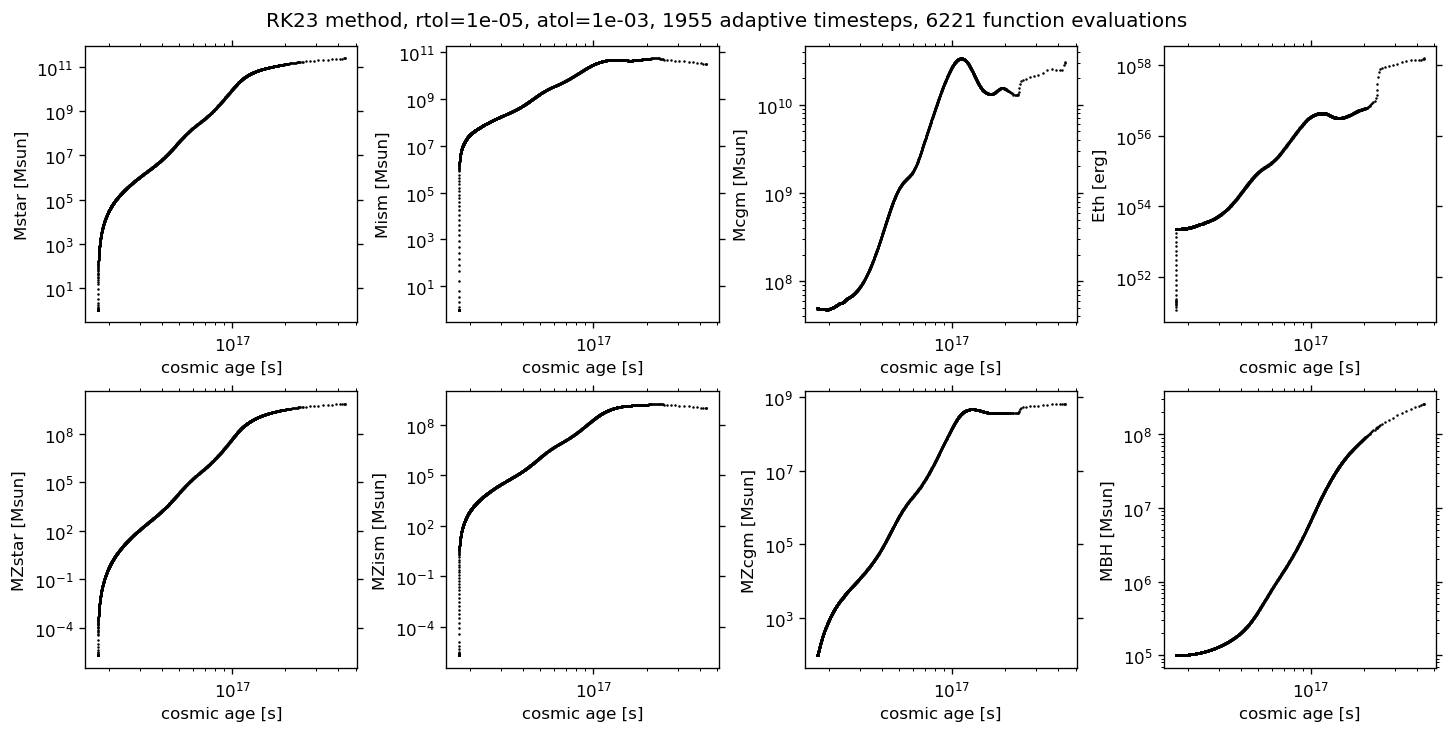

In [12]:
labels = {0:'Mstar [Msun]',1:'Mism [Msun]',2:'Mcgm [Msun]',3:'Eth [erg]',4:'MZstar [Msun]',5:'MZism [Msun]',6:'MZcgm [Msun]',7:'MBH [Msun]'}
          
fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(12,6),constrained_layout=True)
allax = np.ravel(axes)
#allax[-1].axis('off')

for varnum in np.arange(8):
    
    allax[varnum].loglog(10**sol.t,10**sol.y[varnum],'k.',ms=3,mec='none')
    allax[varnum].set_xlabel('cosmic age [s]')
    allax[varnum].set_ylabel(labels[varnum])
    
fig.suptitle('%s method, rtol=%.0e, atol=%.0e, %i adaptive timesteps, %i function evaluations'%(ode_method,rtol,atol,len(sol.t),sol.nfev))

# plt.savefig('solve_ivp_logarithmic_%s_%s_benchmark.png'%(halo_name,ode_method),bbox_inches='tight',dpi=150,facecolor='white')

In [50]:
# run solve_ivp with updated parameters  

parameters.update({'etaE_A':1.0,'etaM_A':1e-5,'etaZ_A':0.0})

tstart = timer()
sol2 = solve_ivp(integrator,[t_init,t_final],initial_conditions,dense_output=True,method=ode_method,
                 atol=atol,rtol=rtol,args=(parameters,))

print('\n',sol2.message,'solve_ivp took %.3f seconds'%(timer()-tstart),'\n')
print(sol2.y.T[-1])

Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.977
Cool func is -2.0e-23
Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is -2.3e-23
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is -2.3e-23
Redshift is 8.977
Cool func is 0.0e+00
Redshift is 8.977
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.977
Cool func is -2.2e-23
Redshift is 8.976
Cool func is 0.0e+00
Redshift is 8.975
Coo

/tmp/ipykernel_1240870/398794705.py:10: RuntimeWarning: overflow encountered in scalar power
  M_ism = 10**logy[1]
/tmp/ipykernel_1240870/398794705.py:14: RuntimeWarning: overflow encountered in scalar power
  MZ_ism = 10**logy[5]
/tmp/ipykernel_1240870/398794705.py:193: RuntimeWarning: invalid value encountered in scalar divide
  Zism = MZ_ism / M_ism # metal mass fraction of ISM
/tmp/ipykernel_1240870/398794705.py:198: RuntimeWarning: invalid value encountered in scalar multiply
  MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
/tmp/ipykernel_1240870/398794705.py:216: RuntimeWarning: invalid value encountered in scalar multiply
  Mdot_ism *= 10**logt / M_ism
/tmp/ipykernel_1240870/1277326743.py:7: RuntimeWarning: invalid value encountered in scalar divide
  T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(0.1*Rvir)**(alpha_n+alpha_T+3))) # K
/tmp/ipykernel_1240870/398794705.py:118: Runti


Cool func is -1.7e-24
Redshift is 8.971
Cool func is -1.7e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.5e-24
Redshift is 8.967
Cool func is -1.8e-24
Redshift is 8.966
Cool func is 0.0e+00
Redshift is 8.970
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.968
Cool func is 0.0e+00
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
C

/tmp/ipykernel_1240870/398794705.py:9: RuntimeWarning: overflow encountered in scalar power
  M_star = 10**logy[0]
/tmp/ipykernel_1240870/398794705.py:11: RuntimeWarning: overflow encountered in scalar power
  M_cgm = 10**logy[2]
/tmp/ipykernel_1240870/398794705.py:12: RuntimeWarning: overflow encountered in scalar power
  Eth_cgm = 10**logy[3]
/tmp/ipykernel_1240870/398794705.py:13: RuntimeWarning: overflow encountered in scalar power
  MZ_star = 10**logy[4]
/tmp/ipykernel_1240870/398794705.py:15: RuntimeWarning: overflow encountered in scalar power
  MZ_cgm = 10**logy[6]
/tmp/ipykernel_1240870/398794705.py:16: RuntimeWarning: overflow encountered in scalar power
  M_BH = 10**logy[7]
/tmp/ipykernel_1240870/398794705.py:82: RuntimeWarning: invalid value encountered in scalar divide
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/tmp/ipykernel_1240870/398794705.py:192: RuntimeWarning: invalid value encountered in scalar divide
  Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not norm

Redshift is 8.968
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.6e-24
Redshift is 8.968
Cool func is -1.6e-24
Redshift is 8.967
Cool func is -1.6e-24
Redshift is 8.967
Cool func is -1.6e-24
Redshift is 8.967
Cool func is -1.6e-24
Redshift is 8.967
Cool func is -1.6e-24
Redshift is 8.967
Cool func is -1.6e-24
Redshift is 8.967
Cool func is -1.6e-24
Redshift is 8.966
Cool func is -1.6e-24
Redshift is 8.966
Cool func is -1.6e-24
Redshift is 8.966
Cool func is -1.6e-24
Redshift is 8.966
Cool func is -1.6e-24
Redshift is 8.965
Cool func is -1.6e-24
Redshift is 8.965
Cool func is -1.6e-24
Redshift is 8.964
Cool func is -1.6e-24
Redshift is 8.964
Cool func is -1.6e-24
Redshift is 8.963
Cool func is -1.6e-24
Redshift is 8.963
Cool func is -1.6e-24
Redshift is 8.962
Cool func is -1.6e-24
Redshift is 8.962
Cool func is -1.6e-24
Redshift is 8.961
Cool func is -1.6e-24
Redshift is 8.960
Cool func is -1.6e-24


Text(0.5, 0.98, 'RK23 method, rtol=1e-05, atol=1e-03, 1511 adaptive timesteps, 4934 function evaluations')

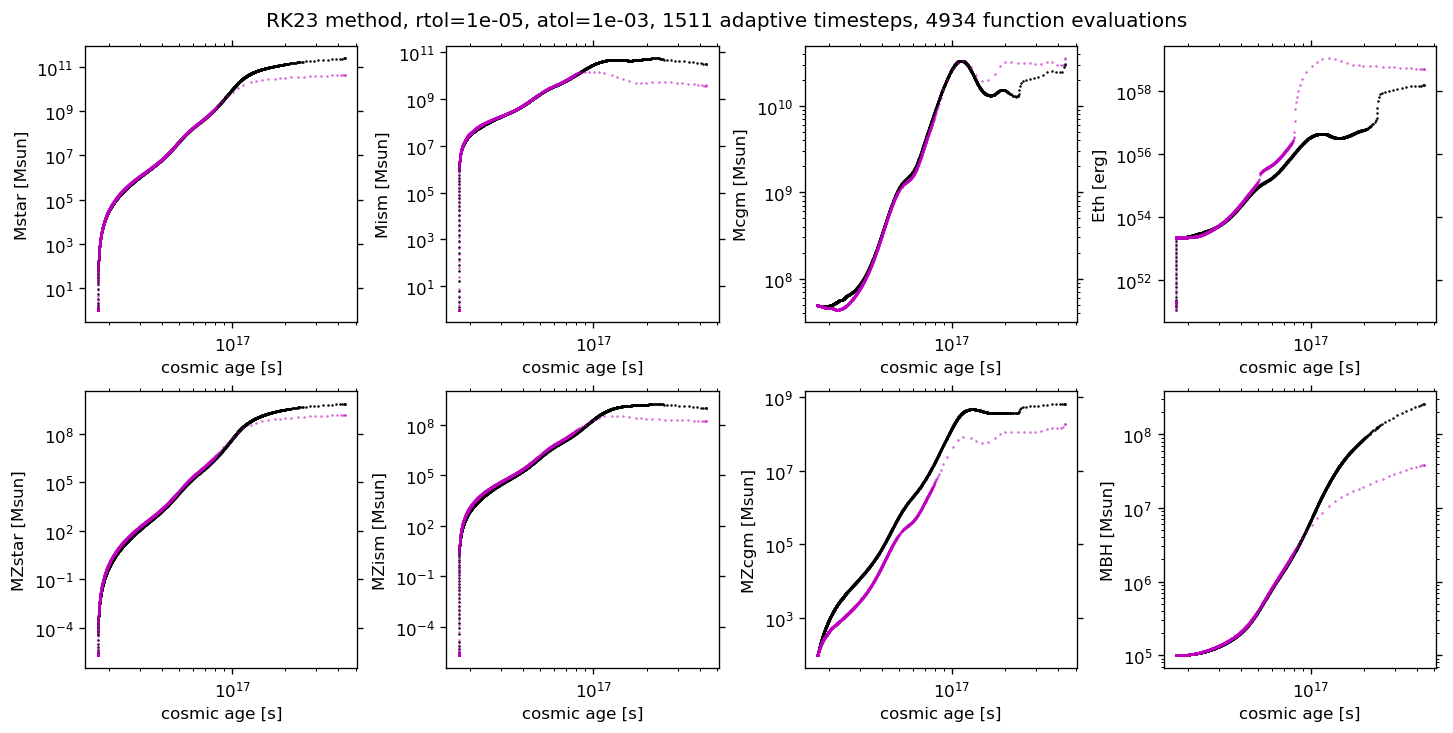

In [51]:
labels = {0:'Mstar [Msun]',1:'Mism [Msun]',2:'Mcgm [Msun]',3:'Eth [erg]',4:'MZstar [Msun]',5:'MZism [Msun]',6:'MZcgm [Msun]',7:'MBH [Msun]'}
          
fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(12,6),constrained_layout=True)
allax = np.ravel(axes)
#allax[-1].axis('off')

for varnum in np.arange(8):
    
    allax[varnum].loglog(10**sol.t,10**sol.y[varnum],'k.',ms=3,mec='none')
    allax[varnum].loglog(10**sol2.t,10**sol2.y[varnum],'m.',ms=3,mec='none',alpha=0.6)    
    allax[varnum].set_xlabel('cosmic age [s]')
    allax[varnum].set_ylabel(labels[varnum])
    
fig.suptitle('%s method, rtol=%.0e, atol=%.0e, %i adaptive timesteps, %i function evaluations'%(ode_method,rtol,atol,len(sol2.t),sol2.nfev))

# plt.savefig('solve_ivp_logarithmic_%s_%s_benchmark.png'%(halo_name,ode_method),bbox_inches='tight',dpi=150,facecolor='white')

Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.959
Cool func is -1.6e-24
Redshift is 8.937
Cool func is -1.6e-24
Redshift is 8.916
Cool func is -1.6e-24
Redshift is 8.895
Cool func is -1.6e-24
Redshift is 8.873
Cool func is -1.5e-24
Redshift is 8.852
Cool func is -1.7e-24
Redshift is 8.831
Cool func is -1.5e-24
Redshift is 8.810
Cool func is -1.5e-24
Redshift is 8.789
Cool func is -1.7e-24
Redshift is 8.768
Cool func is -1.7e-24
Redshift is 8.747
Cool func is -1.7e-24
Redshift is 8.726
Cool func is -1.6e-24
Redshift is 8.705
Cool func is -1.5e-24
Redshift is 8.684
Cool func is -1.7e-24
Redshift is 8.663
Cool func is -1.6e-24
Redshift is 8.642
Cool func is -1.7e-24
Redshift is 8.622
Cool func is -1.5e-24
Redshift is 8.601
Cool func is -1.6e-24
Redshift is 8.580
Cool func is -1.7e-24
Redshift is 8.560
Cool func is -1.7e-24
Redshift is 8.539
Cool func is -1.7e-24
Redshift is 8.519
Cool func is -1.6e-24
Redshift is 8.498
Cool func is -1.5e-24
Redshift is 8.478
Cool func is -1.6e-24
R

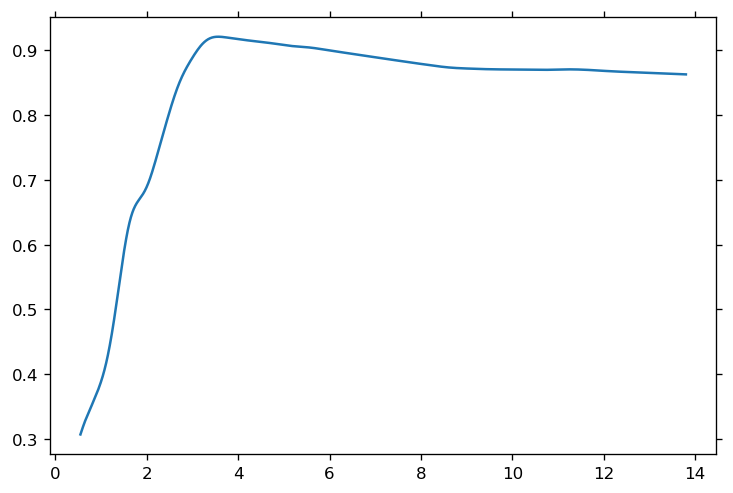

In [45]:
##### create dict of time evolution of ALL properties (state+intermediary variables) for plotting

# create denser solution
dense_sol = sol2.sol(t_eval)

# first update parameters dict to return everything
parameters.update(return_all=True) 

# store the output dict for each set of [time,state_variables] in the sol object
out_dicts = [integrator(t_eval[tsol],dense_sol[:,tsol],parameters) for tsol in range(len(t_eval))]

# use dict comprehension to combine all dicts so I have a list of each property vs time
comb_dict = {key: [d.get(key) for d in out_dicts] for key in set(out_dicts[0].keys())}

# finally revert parameters dict to set return_all back to False just in case... 
parameters.update(return_all=False) 

fig, axes = plt.subplots(1,constrained_layout=True)

axes.plot(comb_dict['cosmic_age'],comb_dict['f_prev'])

In [46]:
# run solve_ivp with updated parameters  

parameters.update({'etaZ_A':0.0})

tstart = timer()
sol3 = solve_ivp(integrator,[t_init,t_final],initial_conditions,dense_output=True,method=ode_method,
                 atol=atol,rtol=rtol,args=(parameters,))

print('\n',sol3.message,'solve_ivp took %.3f seconds'%(timer()-tstart),'\n')
print(sol3.y.T[-1])

Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.977
Cool func is -2.0e-23
Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.980
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is -2.3e-23
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is -2.3e-23
Redshift is 8.977
Cool func is 0.0e+00
Redshift is 8.977
Cool func is 0.0e+00
Redshift is 8.979
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.978
Cool func is 0.0e+00
Redshift is 8.977
Cool func is -2.2e-23
Redshift is 8.976
Cool func is 0.0e+00
Redshift is 8.975
Coo

/tmp/ipykernel_1240870/398794705.py:10: RuntimeWarning: overflow encountered in scalar power
  M_ism = 10**logy[1]
/tmp/ipykernel_1240870/398794705.py:14: RuntimeWarning: overflow encountered in scalar power
  MZ_ism = 10**logy[5]
/tmp/ipykernel_1240870/398794705.py:193: RuntimeWarning: invalid value encountered in scalar divide
  Zism = MZ_ism / M_ism # metal mass fraction of ISM
/tmp/ipykernel_1240870/398794705.py:198: RuntimeWarning: invalid value encountered in scalar multiply
  MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
/tmp/ipykernel_1240870/398794705.py:216: RuntimeWarning: invalid value encountered in scalar multiply
  Mdot_ism *= 10**logt / M_ism
/tmp/ipykernel_1240870/1277326743.py:7: RuntimeWarning: invalid value encountered in scalar divide
  T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(0.1*Rvir)**(alpha_n+alpha_T+3))) # K
/tmp/ipykernel_1240870/398794705.py:118: Runti

Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.968
Cool func is 0.0e+00
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is 0.0e+00
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is 0.0e+00
Redshift is 8.969
Cool func is -1.6e-24
Redshift is 8.969
Cool func is -1.6e-24
Red

Text(0.5, 0.98, 'RK23 method, rtol=1e-05, atol=1e-03, 1511 adaptive timesteps, 4934 function evaluations')

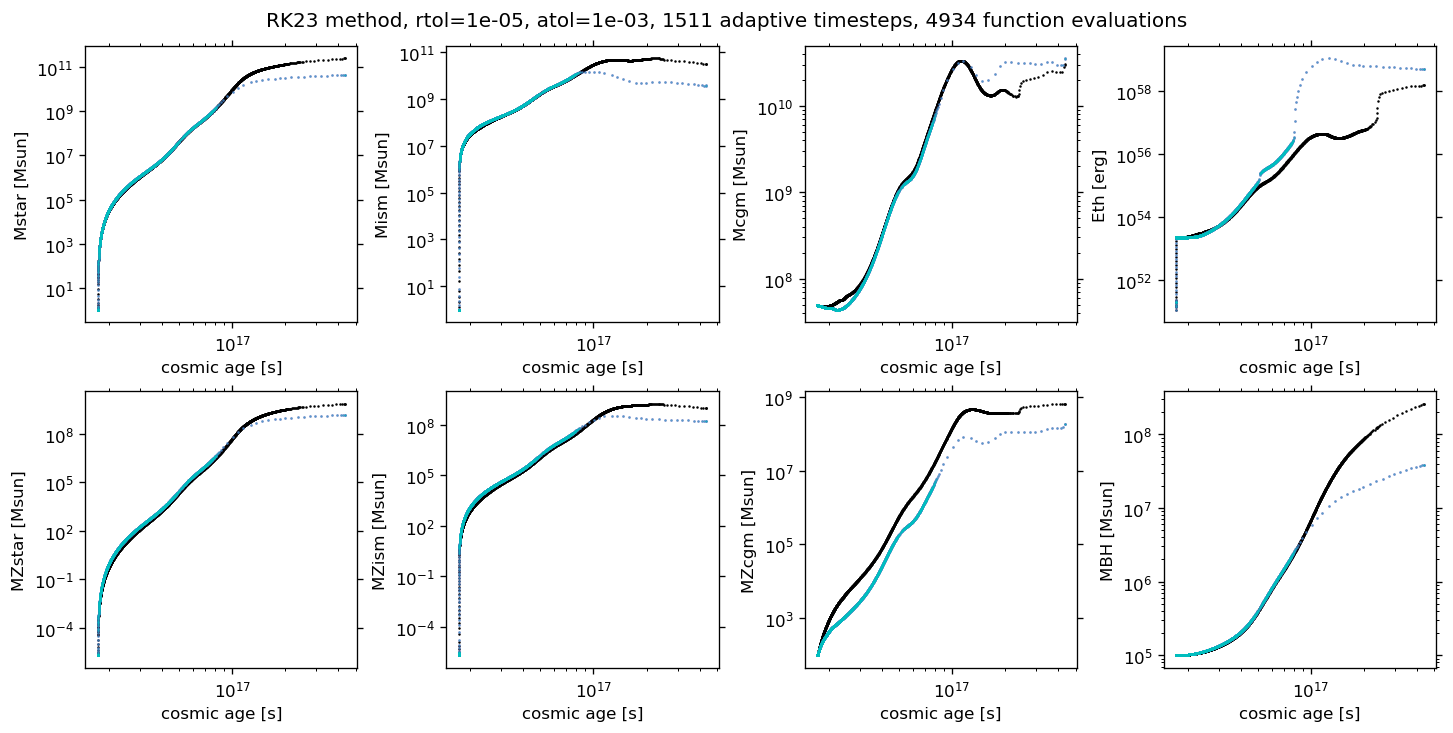

In [47]:
labels = {0:'Mstar [Msun]',1:'Mism [Msun]',2:'Mcgm [Msun]',3:'Eth [erg]',4:'MZstar [Msun]',5:'MZism [Msun]',6:'MZcgm [Msun]',7:'MBH [Msun]'}
          
fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(12,6),constrained_layout=True)
allax = np.ravel(axes)
#allax[-1].axis('off')

for varnum in np.arange(8):
    
    allax[varnum].loglog(10**sol.t,10**sol.y[varnum],'k.',ms=3,mec='none')
    allax[varnum].loglog(10**sol2.t,10**sol2.y[varnum],'m.',ms=3,mec='none',alpha=0.6)    
    allax[varnum].loglog(10**sol3.t,10**sol3.y[varnum],'c.',ms=3,mec='none',alpha=0.6)        
    allax[varnum].set_xlabel('cosmic age [s]')
    allax[varnum].set_ylabel(labels[varnum])
    
fig.suptitle('%s method, rtol=%.0e, atol=%.0e, %i adaptive timesteps, %i function evaluations'%(ode_method,rtol,atol,len(sol3.t),sol3.nfev))

# plt.savefig('solve_ivp_logarithmic_%s_%s_benchmark.png'%(halo_name,ode_method),bbox_inches='tight',dpi=150,facecolor='white')

In [48]:
coolfunc_W09([1,-4,4,-3])

array([-4.32329946e-24])